## 1. Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)

## 2. Gerando dados simulados de vendas de veículos

Vamos simular clientes com:

- renda anual
- idade
- preço do veículo comprado
- número de parcelas

In [3]:
n = 300

renda = np.random.normal(loc=50000, scale=15000, size=n)
idade = np.random.randint(20, 70, size=n)

# Perfis de compra diferentes
preco_veiculo = (
    renda * np.random.uniform(0.3, 0.7, size=n)
    + np.random.normal(0, 5000, size=n)
)

parcelas = np.clip(
    np.random.normal(loc=48, scale=12, size=n).astype(int),
    12, 72
)

dados = pd.DataFrame({
    "Renda_Anual": renda,
    "Idade": idade,
    "Preco_Veiculo": preco_veiculo,
    "Parcelas": parcelas
})

dados.head()

,Renda_Anual,Idade,Preco_Veiculo,Parcelas
0,53769.584612,61,24767.734602,42
1,49976.742412,26,36789.465441,34
2,44227.371771,41,16804.077522,65
3,56959.584244,52,32614.728815,27
4,43421.191906,36,26480.318407,40


## 3. Exploração inicial dos dados

In [4]:
print(dados.describe())

        Renda_Anual       Idade  Preco_Veiculo    Parcelas
count    300.000000  300.000000     300.000000  300.000000
mean   49136.283448   44.106667   23839.377800   47.470000
std    14706.926172   14.194137   10131.026938   11.798012
min     6675.931922   20.000000   -1617.887363   15.000000
25%    39303.913581   32.000000   16850.411675   39.000000
50%    49628.645302   44.000000   23260.799058   48.000000
75%    58727.692498   56.250000   30687.269051   56.000000
max    86973.164538   69.000000   52750.503001   72.000000


## 4. Visualização dos padrões de compra
Relação entre renda e preço do veículo.

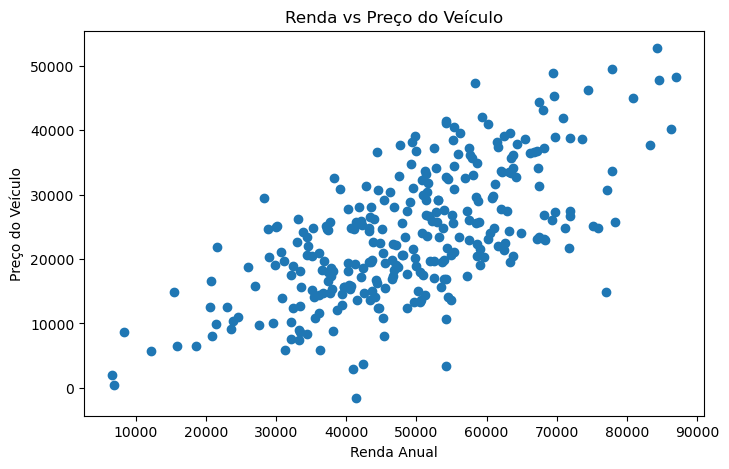

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(dados["Renda_Anual"], dados["Preco_Veiculo"])
plt.xlabel("Renda Anual")
plt.ylabel("Preço do Veículo")
plt.title("Renda vs Preço do Veículo")
plt.show()

## 5. Agrupamento de clientes (Clustering)

Vamos descobrir perfis de compradores automaticamente.

In [7]:
features = dados[["Renda_Anual", "Preco_Veiculo", "Parcelas"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
dados["Grupo_Cliente"] = kmeans.fit_predict(X_scaled)

dados.head()

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,Renda_Anual,Idade,Preco_Veiculo,Parcelas,Grupo_Cliente
0,53769.584612,61,24767.734602,42,0
1,49976.742412,26,36789.465441,34,0
2,44227.371771,41,16804.077522,65,2
3,56959.584244,52,32614.728815,27,0
4,43421.191906,36,26480.318407,40,1


## 6. Visualizando os grupos encontrados

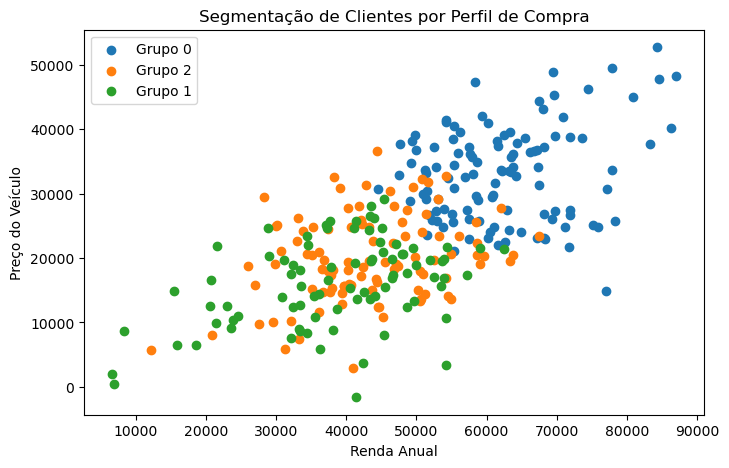

In [9]:
plt.figure(figsize=(8,5))

for grupo in dados["Grupo_Cliente"].unique():
    subset = dados[dados["Grupo_Cliente"] == grupo]
    plt.scatter(subset["Renda_Anual"], subset["Preco_Veiculo"], label=f"Grupo {grupo}")

plt.xlabel("Renda Anual")
plt.ylabel("Preço do Veículo")
plt.title("Segmentação de Clientes por Perfil de Compra")
plt.legend()
plt.show()

## 7. Interpretação dos grupos

In [10]:
dados.groupby("Grupo_Cliente").mean()

,Renda_Anual,Idade,Preco_Veiculo,Parcelas
Grupo_Cliente,,,,
0,62401.933164,44.185841,33092.993945,45.637168
1,38603.187897,44.174419,16146.923104,37.127907
2,43263.291365,43.960396,20036.333042,58.326733


### Para pensar:

- qual grupo compra veículos mais caros?
- quem parcela mais?
- existe relação entre renda e financiamento?